# ETFs: Label Engineering

The label is what every model here is trained to predict, so a defect in it is
invisible downstream and fatal downstream. This notebook defines the labels, proves the
definitions sound, measures one baseline signal to set the floor before any feature
work, and writes the label files stage 03 reads.

## Learning objectives

- Express a forward-return label as an execution convention: from which tradable price
  at which time, to which tradable price at which time
- Prove every labelled row has a complete, gap-free forward window inside one entity
- Size the independent information in an overlapping label, and seal a diagnostic on the
  label's endpoint rather than on its observation date
- Establish the baseline a feature must clear, under a standard error that prices in the
  overlap

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2; Section 7.3's apparatus belongs to `05_evaluation`. Reads split-
and dividend-adjusted daily bars via `load_etfs()` (verified in
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb)) and `config/setup.yaml`,
which declares the label set, horizons and holdout boundary. Writes
`labels/fwd_ret_21d.parquet` and `labels/fwd_ret_5d.parquet`, each with a `.digest.json`
sidecar. `03_financial_features.py` reads whichever is `labels.primary`, for its feature
evaluation only; nothing reads the sidecars yet - see section H.

In [1]:
"""ETFs: Label Engineering."""

import math
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_etfs
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("etfs")
LABELS_DIR = CASE_DIR / "labels"

In [2]:
# Production runs the first two as None; CI overrides them to reduce the universe and span.
MAX_SYMBOLS = None
START_DATE = None
# F4 takes a standard deviation across symbols on each date, and across two or three symbols
# that is noise rather than dispersion, so thinner dates are dropped instead of being allowed
# to set a year's level. CI reduces the universe below this floor and overrides it in step.
MIN_SYMBOLS_FOR_DISPERSION = 10

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and bound here: a
horizon or boundary typed into a cell is a second copy that drifts from the one the rest
of the pipeline reads. `resolve_label_horizon` prefers an explicit `labels.horizons`
entry and falls back to the CV buffer. They are separate fields - the buffer that keeps
folds independent is not always the horizon the outcome resolves over - and coincide
here.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = setup["labels"]["primary"]
LABEL_NAMES = [PRIMARY_LABEL, *setup["labels"].get("variants", [])]
HORIZONS = {n: int(resolve_label_horizon("etfs", n, setup).rstrip("Dd")) for n in LABEL_NAMES}
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
PRIMARY_HORIZON = HORIZONS[PRIMARY_LABEL]
VARIANT_LABEL = LABEL_NAMES[1]

print(f"Labels: {LABEL_NAMES} (primary: {PRIMARY_LABEL})")
print(f"Horizons, trading sessions: {HORIZONS}")
print(f"Holdout starts {HOLDOUT_START}; diagnostics below are sealed on the label endpoint")

Labels: ['fwd_ret_21d', 'fwd_ret_5d'] (primary: fwd_ret_21d)
Horizons, trading sessions: {'fwd_ret_21d': 21, 'fwd_ret_5d': 5}
Holdout starts 2024-01-01; diagnostics below are sealed on the label endpoint


## A. The learning task

The hypothesis is cross-sectional: among a fixed universe of liquid ETFs, those that have
risen over the past two quarters continue to outrank those that have not over the
following month. The label is therefore a *relative* forward return measured over a window
a monthly hold spans. `setup.yaml` sets the decision cadence to a month-end close with
execution at the next open, fixing the primary horizon at one trading month; the weekly
variant asks whether the same hypothesis pays over a shorter hold, which is a question
about turnover and cost, not a second hypothesis. Labels are sampled every session rather
than only at month ends: daily sampling buys an order of magnitude more rows at the price
of overlapping windows, and Section F measures what they are worth.

## B. Preparation before the label

A forward window is meaningful only on a price series that is adjusted, ordered and
complete; sorting by `symbol` then `timestamp` is what makes a shift mean "the next
session for this ETF". **No eligibility filter is applied here, and that ordering is not
a detail.** Dropping
ineligible rows before a forward shift makes the shift count surviving rows, so the
horizon stops being measured in trading sessions and the label silently spans the gap.
Point-in-time eligibility (`eligibility.csv`) is enforced in `03_financial_features`,
where the trainable panel is assembled - after the label exists.

In [4]:
prices = load_etfs().select(["symbol", "timestamp", "close"]).sort(["symbol", "timestamp"])

if START_DATE is not None:
    prices = prices.filter(pl.col("timestamp") >= date.fromisoformat(START_DATE))
if MAX_SYMBOLS is not None:
    prices = prices.filter(
        pl.col("symbol").is_in(sorted(prices["symbol"].unique().to_list())[:MAX_SYMBOLS])
    )

# Digest of the data the labels are built from, recorded as every label's `inputs`: a
# re-run against a refreshed download is otherwise indistinguishable from this one.
MARKET_DATA_DIGEST = value_digest(prices, ["symbol", "timestamp", "close"])

print(f"{prices['symbol'].n_unique()} ETFs, {len(prices):,} rows")
print(f"Sessions {prices['timestamp'].min()} to {prices['timestamp'].max()}")
print(f"market_data digest: {MARKET_DATA_DIGEST}")

100 ETFs, 470,662 rows
Sessions 2006-01-03 to 2025-12-31
market_data digest: eef04b58a9ea0b97


## C. Label construction

One execution convention, written once, applied to both horizons:

$$\text{fwd\_ret}^{(h)}_{i,t} = \frac{P_{i,t+h}}{P_{i,t}} - 1$$

where $P$ is the adjusted close and $t+h$ counts $h$ **trading sessions** for symbol $i$:
Chapter 7.2's close-to-close convention. It is a deliberate choice of target rather than a
forced one - `setup.yaml` places execution at the next open, and these bars carry an open,
so a next-open target is expressible. Close-to-close is chosen because it is the
convention Chapter 7 develops and the one the literature reports. The difference between
it and the backtest's fill is a real gap and this case study does not measure it: `16_costs`
sweeps commission and half-spread, not the return definition. Both labels share the anchor
and differ only in $h$; Section H prints each full definition.

The arithmetic stays local rather than calling `fixed_time_horizon_labels`, which computes
the algebraically identical $(P_{t+h}-P_t)/P_t$: the two agree only to within a
floating-point rounding step, which is enough to change the artifact digest and every
value derived from it. Adopting the library call is a change to make once, deliberately,
across all nine case studies.

In [5]:
def forward_return(df: pl.DataFrame, horizon: int, name: str) -> pl.DataFrame:
    """Close-to-close forward return over `horizon` trading sessions, per symbol."""
    return df.with_columns(
        (pl.col("close").shift(-horizon).over("symbol") / pl.col("close") - 1).alias(name)
    )


labels_df = prices.with_columns(
    (pl.len().over("symbol") - 1 - pl.int_range(pl.len()).over("symbol")).alias("from_end")
)
for label_name, horizon in HORIZONS.items():
    labels_df = forward_return(labels_df, horizon, label_name)

print(f"Constructed {', '.join(LABEL_NAMES)}")

Constructed fwd_ret_21d, fwd_ret_5d


## D. Window validity

A shift always returns something; the question is whether it is the quantity the label
claims. The four properties below all fail silently, so they are asserted rather than
described. The tolerance for the second is derived, not tuned: $h$ trading sessions span
about $7h/5$ calendar days on a five-session week, plus a week for exchange holidays.

Note what that second property does and does not establish. It bounds a window's *calendar*
span, so it catches a hole of a week or more - a delisting, an outage, a symbol that stops
and resumes - but not one missing session, which widens the window by a day and stays
inside the tolerance. Proving exactly $h$ *exchange* sessions needs a session calendar this
notebook does not carry. The convention is $h$ sessions as they appear in this data, and
the assertion bounds how far that can drift from $h$ sessions on the exchange.

In [6]:
for label_name, horizon in HORIZONS.items():
    tol = math.ceil(horizon * 7 / 5) + 7
    # How many calendar days the forward window actually spans, for property 2.
    spanned = labels_df.with_columns(
        (pl.col("timestamp").shift(-horizon).over("symbol") - pl.col("timestamp"))
        .dt.total_days()
        .alias("_span")
    )
    tail = spanned.filter(pl.col("from_end") < horizon)
    labelled = spanned.drop_nulls(label_name)

    # 1. An incomplete forward window is null, never a value.
    assert tail[label_name].null_count() == tail.height, f"{label_name}: valued incomplete window"
    # 2. A window spanning a gap wider than tolerance would be null; none exist here.
    assert labelled.filter(pl.col("_span") > tol).height == 0, f"{label_name}: window gap"
    # 3. No label crosses an entity boundary: the labelled count equals the bar count less
    #    `horizon` rows per symbol, which holds only if every window closed in its symbol.
    assert labelled.height == len(prices) - horizon * prices["symbol"].n_unique(), (
        f"{label_name}: label crosses a symbol boundary"
    )
    # 4. No discrete label is derived from a null return - vacuous here by dtype, since
    #    this notebook writes continuous labels only and that defect lives in direction
    #    labels, where a null predicate falls through to the "down" class.
    assert labels_df.schema[label_name] == pl.Float64, f"{label_name}: unexpected dtype"

    spans = labelled["_span"]
    print(
        f"{label_name}: {labelled.height:,} labelled rows, spans {spans.min()}-{spans.max()}d "
        f"against a {tol}d tolerance, {tail.height:,} tail rows null"
    )

fwd_ret_21d: 468,562 labelled rows, spans 29-35d against a 37d tolerance, 2,100 tail rows null
fwd_ret_5d: 470,162 labelled rows, spans 7-12d against a 14d tolerance, 500 tail rows null


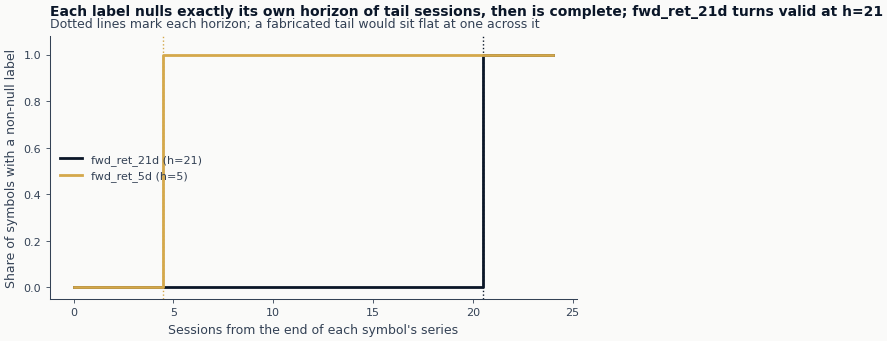

In [7]:
# F2. Validity at the window boundary. Position zero is each symbol's last session; the
# non-null rate must fall to zero over exactly the last `horizon` positions and be flat at
# one before. A scalar "N valid" shows neither failure this catches - a label masked by
# another label's null set, or a tail fabricated instead of nulled. It reads only the null
# structure, never a value, so it is not sealed: it describes the artifact's shape.
profile = (
    labels_df.filter(pl.col("from_end") <= max(HORIZONS.values()) + 3)
    .group_by("from_end")
    .agg([pl.col(n).is_not_null().mean().alias(n) for n in LABEL_NAMES])
    .sort("from_end")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for label_name, color in zip(LABEL_NAMES, (COLORS["blue"], COLORS["amber"]), strict=True):
    ax.step(
        profile["from_end"],
        profile[label_name],
        where="mid",
        color=color,
        linewidth=2,
        label=f"{label_name} (h={HORIZONS[label_name]})",
    )
    ax.axvline(HORIZONS[label_name] - 0.5, color=color, linestyle=":", linewidth=1)
ax.set_xlabel("Sessions from the end of each symbol's series")
ax.set_ylabel("Share of symbols with a non-null label")
ax.set_ylim(-0.05, 1.08)
add_message_title(
    ax,
    f"Each label nulls exactly its own horizon of tail sessions, then is complete; "
    f"{PRIMARY_LABEL} turns valid at h={PRIMARY_HORIZON}",
    subtitle="Dotted lines mark each horizon; a fabricated tail would sit flat at one across it",
)
ax.legend(loc="center left", frameon=False)
plt.show()

## E. Distribution and base rate

What scale is the label, and is that scale stable enough through time that a model fitted
on one regime measures the same quantity in another? Everything from here through Section
G is computed on the **development window only**, sealed on the label's endpoint rather
than its observation date: a row observed just before the holdout still resolves inside
it. The label files keep every row - the seal governs what this notebook may look at, not
what it writes.

In [8]:
dev = {
    name: labels_df.with_columns(
        pl.col("timestamp").shift(-horizon).over("symbol").alias("_label_end")
    )
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls(name)
    for name, horizon in HORIZONS.items()
}
for label_name, frame in dev.items():
    print(f"{label_name}: {frame.height:,} development rows through {frame['timestamp'].max()}")

fwd_ret_21d: 418,362 development rows through 2023-11-29
fwd_ret_5d: 419,962 development rows through 2023-12-21


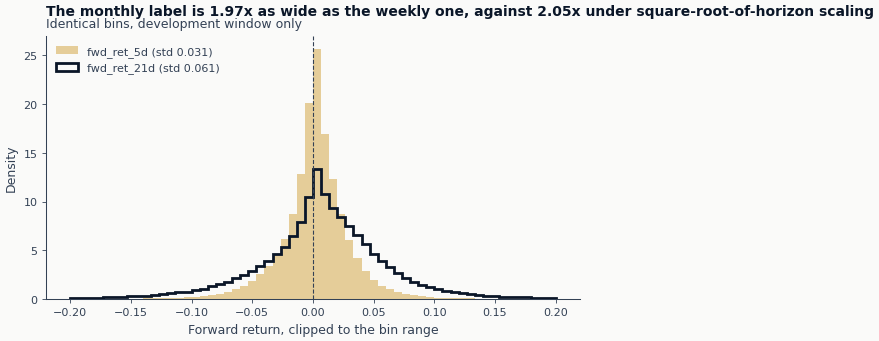

In [9]:
# F1. Both labels on one shared axis with identical bins. The horizon scaling - a label
# roughly sqrt(h) times wider - is a claim about shape a column of moments cannot support.
bins = np.linspace(-0.20, 0.20, 61)
std = {n: dev[n][n].std() for n in LABEL_NAMES}
ratio = std[PRIMARY_LABEL] / std[VARIANT_LABEL]
theory = math.sqrt(PRIMARY_HORIZON / HORIZONS[VARIANT_LABEL])

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fills = {VARIANT_LABEL: dict(color=COLORS["amber"], alpha=0.55)}
fills[PRIMARY_LABEL] = dict(color=COLORS["blue"], histtype="step", linewidth=2)
for label_name in (VARIANT_LABEL, PRIMARY_LABEL):
    ax.hist(
        dev[label_name][label_name].to_numpy(),
        bins=bins,
        density=True,
        label=f"{label_name} (std {std[label_name]:.3f})",
        **fills[label_name],
    )
ax.axvline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.8)
ax.set_xlabel("Forward return, clipped to the bin range")
ax.set_ylabel("Density")
add_message_title(
    ax,
    f"The monthly label is {ratio:.2f}x as wide as the weekly one, against {theory:.2f}x "
    f"under square-root-of-horizon scaling",
    subtitle="Identical bins, development window only",
)
ax.legend(loc="upper left", frameon=False)
plt.show()

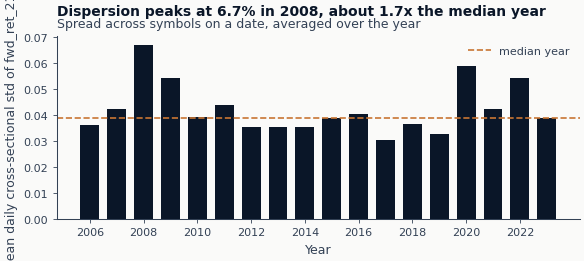

scale: std ratio 1.97 against 2.05 under root-horizon scaling; dispersion peaks at 6.7% in 2008 against a 3.9% median year


In [10]:
# F4. Dispersion through time. A cross-sectional label is comparable across regimes only
# if the spread the model ranks within is roughly stable; where it is not, the same IC buys
# a different amount of return.
#
# The spread is taken across symbols on each date first, and only then averaged over the
# year. Pooling every symbol-date in the year into one standard deviation instead would
# measure something else - it would add the movement of the panel's own mean from date to
# date to the spread across symbols on a date, and it is only the second that a
# cross-sectional ranking model is scored on.
daily_dispersion = (
    dev[PRIMARY_LABEL]
    .group_by("timestamp")
    .agg(pl.col(PRIMARY_LABEL).std().alias("dispersion"), pl.len().alias("n_symbols"))
    .filter(pl.col("n_symbols") >= MIN_SYMBOLS_FOR_DISPERSION)
)
annual = (
    daily_dispersion.with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("dispersion").mean().alias("dispersion"))
    .sort("year")
)
peak = annual.sort("dispersion", descending=True).row(0, named=True)
median_disp = annual["dispersion"].median()

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.bar(annual["year"], annual["dispersion"], color=COLORS["blue"], width=0.7)
ax.axhline(median_disp, color=COLORS["copper"], linestyle="--", linewidth=1.2, label="median year")
ax.set_xticks(annual["year"].to_list()[::2])  # integer years, not a float axis
ax.set_xlabel("Year")
ax.set_ylabel(f"Mean daily cross-sectional std of {PRIMARY_LABEL}")
add_message_title(
    ax,
    f"Dispersion peaks at {peak['dispersion']:.1%} in {peak['year']:.0f}, about "
    f"{peak['dispersion'] / median_disp:.1f}x the median year",
    subtitle="Spread across symbols on a date, averaged over the year",
)
ax.legend(loc="upper right", frameon=False)
plt.show()

print(
    f"scale: std ratio {ratio:.2f} against {theory:.2f} under root-horizon scaling; "
    f"dispersion peaks at {peak['dispersion']:.1%} in {peak['year']:.0f} "
    f"against a {median_disp:.1%} median year"
)

On the development window the monthly label has a standard deviation of 0.0612 against
0.0311 for the weekly label - a ratio of 1.97, close to the 2.05 that
square-root-of-horizon scaling would give. Cross-sectional dispersion is far from
constant: it peaks at 6.7% in 2008, against a median year of 3.9%.

## F. Overlap and effective sample size

Daily sampling of a multi-session label makes consecutive rows share most of their forward
window, so the row count overstates the information the sample carries. Two measurements:
how fast the overlap decays, and what the row count is worth once it is priced in.
`effective_sample_size` applies Chapter 7.2's average-uniqueness weighting per symbol,
because concurrency is a property of one entity's overlapping windows.

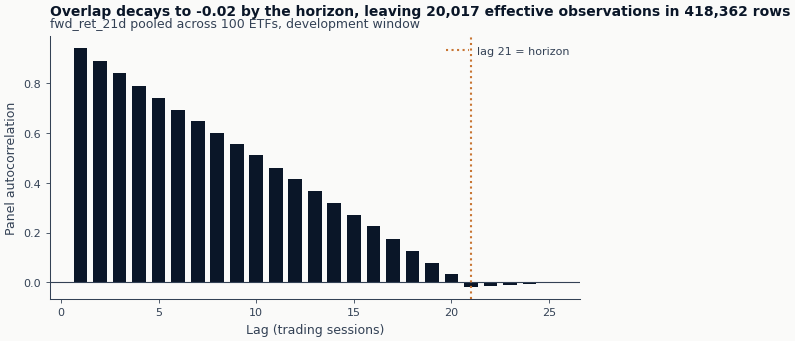

fwd_ret_21d: N=418,362 N_eff=20,017 (4.78% of N, against 4.76% for windows that overlap as fully as this one)
  autocorrelation at lag one 0.942, at the horizon -0.019


In [11]:
# F3. Overlap decay across the panel. Computed on one asset this would be a claim about
# that asset: pooled and single-symbol estimates disagree most at the lag that matters.
max_lag = PRIMARY_HORIZON + 4
acf = panel_autocorrelation(dev[PRIMARY_LABEL], PRIMARY_LABEL, max_lag=max_lag)
n_rows, n_eff = effective_sample_size(dev[PRIMARY_LABEL], horizon=PRIMARY_HORIZON)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.bar(np.arange(1, max_lag + 1), acf, color=COLORS["blue"], width=0.7)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.8)
ax.axvline(
    PRIMARY_HORIZON,
    color=COLORS["copper"],
    linestyle=":",
    linewidth=1.5,
    label=f"lag {PRIMARY_HORIZON} = horizon",
)
ax.set_xlabel("Lag (trading sessions)")
ax.set_ylabel("Panel autocorrelation")
add_message_title(
    ax,
    f"Overlap decays to {acf[PRIMARY_HORIZON - 1]:.2f} by the horizon, leaving "
    f"{n_eff:,.0f} effective observations in {n_rows:,} rows",
    subtitle=f"{PRIMARY_LABEL} pooled across "
    f"{dev[PRIMARY_LABEL]['symbol'].n_unique()} ETFs, development window",
)
ax.legend(loc="upper right", frameon=False)
plt.show()

# A horizon-h label consumes the h returns realised over its window, and its neighbour
# one bar later shares h-1 of them, so average uniqueness converges to 1/h.
print(
    f"{PRIMARY_LABEL}: N={n_rows:,} N_eff={n_eff:,.0f} ({n_eff / n_rows:.2%} of N, against "
    f"{1 / PRIMARY_HORIZON:.2%} for windows that overlap as fully as this one)"
)
print(f"  autocorrelation at lag one {acf[0]:.3f}, at the horizon {acf[PRIMARY_HORIZON - 1]:.3f}")

The monthly label's 418,362 development rows carry 20,017 effective observations - 4.78%
of the row count, against the 4.76% that a window this fully overlapped implies. The
autocorrelation runs from 0.942 at lag one to -0.019 at the horizon. Both say the same
thing in different units: the sample is worth about a twentieth of what its height
suggests, and the purge gap between folds must be at least the horizon.

## G. Baseline floor

One signal, against the primary label, on the sealed development window: the raw momentum
the hypothesis names, with no feature engineering. Establishing this floor before
feature work is what keeps a later improvement honest. The IC is the per-date
cross-sectional rank correlation averaged over dates - never pooled across dates, which
mixes a cross-sectional claim with a time-series one. The minimum cross-section is half
the median cross-section rather than a bare integer, so it means the same thing in a case
study of a different size. The standard error is HAC-adjusted: the IC series inherits the
label's overlap, so the naive statistic treats correlated dates as independent evidence.

In [12]:
LOOKBACK = 126  # two quarters, the momentum window the hypothesis names

baseline = (
    dev[PRIMARY_LABEL]
    .with_columns(
        (pl.col("close") / pl.col("close").shift(LOOKBACK).over("symbol") - 1).alias("momentum")
    )
    .drop_nulls("momentum")
)
min_obs = int(baseline.group_by("timestamp").len()["len"].median() // 2)

ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="momentum",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=min_obs,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=PRIMARY_HORIZON)

print(f"Baseline: {LOOKBACK}-session momentum vs {PRIMARY_LABEL}, min cross-section {min_obs}")
print(f"  dates {ic.height:,}, mean IC {stats['mean_ic']:.4f}")
print(
    f"  HAC t {stats['t_stat']:.2f} (Bartlett, {stats['effective_lags']} lags), "
    f"naive t {stats['naive_t_stat']:.2f}, p {stats['p_value']:.3f}"
)

Baseline: 126-session momentum vs fwd_ret_21d, min cross-section 49
  dates 4,382, mean IC 0.0257
  HAC t 1.44 (Bartlett, 20 lags), naive t 5.07, p 0.151


Raw momentum earns a mean IC of 0.0257 against the monthly label. Under the naive
standard error that is a t-statistic of 5.07; once the overlap is priced in it is 1.44,
with a p-value of 0.151. The bar a feature has to clear is the second number.

## H. Artifacts and the audit record

Each label is written with a digest sidecar recording its content hash, row count, key
columns and the digest of the price data it was built from.

A model run is already pinned to the label *bytes* it trained on:
`_training_input_identity` in `case_studies/utils/latent_factors/case_study.py` hashes the
label parquet, the feature parquets and `setup.yaml` into one aggregate digest, which the
training stages (`07`-`10`, and the latent-factor path) record in their spec. Two runs on
different label vintages are distinguishable there.

The sidecar itself is not read anywhere yet. It makes the label self-describing at the
point it is written, which is the part this notebook owns; whether a stage that consumes
labels should also record the digest it consumed is a decision for that stage.

**No `cv_config.json` is written here**: the folds that train models are derived by
`case_studies/utils/cv_window.py` from `setup.yaml` and the label parquet's own timeline -
that is, from this notebook's artifact rather than from a second file describing it. A
committed copy would only drift from the folds actually in force.

In [13]:
for label_name in LABEL_NAMES:
    record = write_artifact(
        labels_df.select(["timestamp", "symbol", label_name]).drop_nulls(),
        LABELS_DIR / f"{label_name}.parquet",
        keys=["timestamp", "symbol"],
        written_by="02_labels",
        inputs={"market_data": MARKET_DATA_DIGEST},
    )
    print(f"{label_name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

fwd_ret_21d.parquet: 468,562 rows, digest fb38c0259c37ef66
fwd_ret_5d.parquet: 470,162 rows, digest d35db10f6a851c96


In [14]:
# The record Chapter 7.2 requires to close a label definition, one row per label, built
# from the values above rather than written by hand.
print("\nLabel audit record")
for label_name, horizon in HORIZONS.items():
    frame = dev[label_name]
    print(
        f"\n{label_name}\n  anchor       adjusted close at t, close-to-close"
        f"\n  horizon      {horizon} trading sessions"
        f"\n  resolution   fixed at t+h; no tie-break needed on daily bars"
        f"\n  overlap      {horizon - 1} sessions shared by consecutive rows"
        f"\n  base rate    mean {frame[label_name].mean():.4f}, std "
        f"{frame[label_name].std():.4f}\n  consumed by  "
        + (
            "03_financial_features.py, as `labels.primary`"
            if label_name == PRIMARY_LABEL
            else "no stage before modelling; stage 03 reads `labels.primary` only"
        )
    )


Label audit record

fwd_ret_21d
  anchor       adjusted close at t, close-to-close
  horizon      21 trading sessions
  resolution   fixed at t+h; no tie-break needed on daily bars
  overlap      20 sessions shared by consecutive rows
  base rate    mean 0.0059, std 0.0612
  consumed by  03_financial_features.py, as `labels.primary`

fwd_ret_5d
  anchor       adjusted close at t, close-to-close
  horizon      5 trading sessions
  resolution   fixed at t+h; no tie-break needed on daily bars
  overlap      4 sessions shared by consecutive rows
  base rate    mean 0.0015, std 0.0311
  consumed by  no stage before modelling; stage 03 reads `labels.primary` only


## Key takeaways

1. **A label is an execution convention, not a shift.** Writing it as a formula - which
   price at which time, to which price at which time - makes it checkable against the
   backtest that has to fill it.
2. **Assert the window, do not describe it.** Every property in Section D fails silently
   and produces plausible numbers when it does: a tail fabricated instead of nulled, a
   window spanning a data gap, a label crossing an entity boundary.
3. **Seal on the label's endpoint.** A row observed before the holdout that resolves
   inside it is a holdout row; filtering on the observation date looks sealed and is not.
4. **Count the information, not the rows.** Overlapping windows make the row count a poor
   guide to the evidence available, which is what the effective count measures. It does
   not set the purge gap - the label's forward window does, and only that: $N_{eff}$ moves
   with sampling density and panel length while the gap a fold needs stays at the horizon.
5. **Establish the floor before building features.** A baseline IC whose standard error
   prices in the overlap is the number a feature has to clear.

**Known limitations.** The close-to-close convention is not the next-open execution the
backtest models, and nothing in this case study measures that difference. The universe is a
fixed, backward-looking list, so the label inherits the survivorship bias documented in
`01_feasibility_analysis`; and the baseline uses one signal at one lookback.

**Next**: `03_financial_features.py` assembles the trainable panel, applies point-in-time
eligibility, and evaluates engineered features against these labels.